<a href="https://colab.research.google.com/github/Noxy-bit/BoliInfo-RAG-Chatbot/blob/main/CHAT_BOT_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

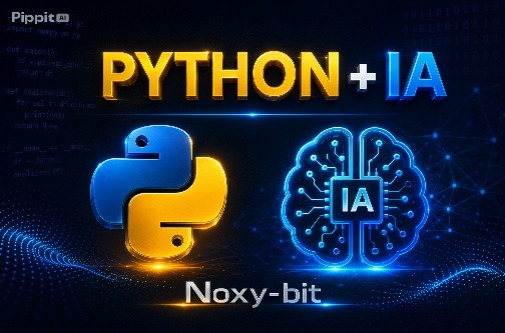

In [16]:
from IPython.display import Image
Image(filename='/content/portada.png')


```
AUTOR: Noxy-bit
```



In [5]:
from google.colab import files
uploaded = files.upload()

Saving prueba.docx.docx to prueba.docx.docx


In [6]:
!pip install python-docx

In [7]:
from docx import Document

def leer_docx(ruta):
    doc = Document(ruta)
    texto = "\n".join([p.text for p in doc.paragraphs])
    return texto

# Obtener nombre del archivo
archivo = list(uploaded.keys())[0]

# Leer contenido
texto = leer_docx(archivo)

print(texto[:1000])  # ver una parte

La Clínica Dental Sonrisa Feliz es un centro especializado en el cuidado de la salud bucal, ubicado en la ciudad. Cuenta con un equipo de profesionales altamente capacitados y tecnología moderna para brindar una atención de calidad a sus pacientes. 
 
Entre los servicios que ofrece la clínica se encuentran la limpieza dental, blanqueamiento, ortodoncia, endodoncia, extracciones y colocación de implantes dentales. Cada tratamiento es personalizado según las necesidades de cada paciente. 
 
La limpieza dental es uno de los servicios más solicitados y consiste en la eliminación de placa bacteriana y sarro para prevenir enfermedades como la gingivitis y la periodontitis. 
 
El blanqueamiento dental permite mejorar la apariencia de los dientes, eliminando manchas y devolviendo su color natural. Este procedimiento es seguro cuando es realizado por profesionales. 
 
La ortodoncia se utiliza para corregir la posición de los dientes y mejorar la mordida. Puede realizarse con brackets tradiciona

In [8]:
def dividir_texto(texto, tamaño=200):
    palabras = texto.split()
    chunks = []

    for i in range(0, len(palabras), tamaño):
        chunk = " ".join(palabras[i:i+tamaño])
        chunks.append(chunk)

    return chunks

chunks = dividir_texto(texto)

print("Cantidad de chunks:", len(chunks))

Cantidad de chunks: 2


In [9]:
def buscar_chunks(pregunta, chunks):
    resultados = []

    for chunk in chunks:
        if any(p.lower() in chunk.lower() for p in pregunta.split()):
            resultados.append(chunk)

    return resultados[:3]

In [10]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 1.4 MB/s eta 0:00:00


In [11]:
from groq import Groq

client = Groq(api_key="INGRESA_TU_KEY")

In [12]:
def preguntar(pregunta):
    resultados = buscar_chunks(pregunta, chunks)

    if not resultados:
        return "No encontré información en el documento."

    contexto = "\n".join(resultados)

    prompt = f"""
Responde SOLO con la información del contexto.

Contexto:
{contexto}

Pregunta: {pregunta}
"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return response.choices[0].message.content

In [ ]:
while True:
    pregunta = input("Tú: ")

    if pregunta.lower() == "salir":
        break

    respuesta = preguntar(pregunta)
    print("Bot:", respuesta)